# Task 2.1 Dataset Selection and Setup

## Dataset Choice
The chosen dataset is a synthetically generated 2-dimensional dataset comprising exactly two distinct clusters. I generated 2000 points for the first cluster centered at `(0,0)` and merely 50 points for the second cluster centered at `(3,0)`, introducing substantial class imbalance alongside modest spatial overlap. 

## Justification
This dataset serves as an ideal testbed specifically for the *Deterministic Anti-Annealing EM* algorithm because it perfectly replicates the core vulnerability described in the paper: highly unbalanced mixing coefficients combined with component overlap. Standard EM converges extraordinarily slowly under a flat likelihood surface when trying to disentangle a small adjacent cluster from a massive one. This synthetic distribution isolates that precise geometric hurdle, allowing DAEM's inverse-temperature hardening mechanism to be transparently tested without high-dimensional noise. 

## Limitations
Unlike the paper's actual MNIST sub-sample experiments, this geometric setup is strictly 2D and artificially Gaussian by definition. The paper evaluates real-world digit image densities (which only roughly approximate Gaussians), whereas this dataset provides an idealized, mathematically pure scenario lacking realistic outlier artifacts or heavy tails.

## Preprocessing
No complex preprocessing was performed aside from randomly shuffling the generated index order to present an unstructured matrix to the algorithm.

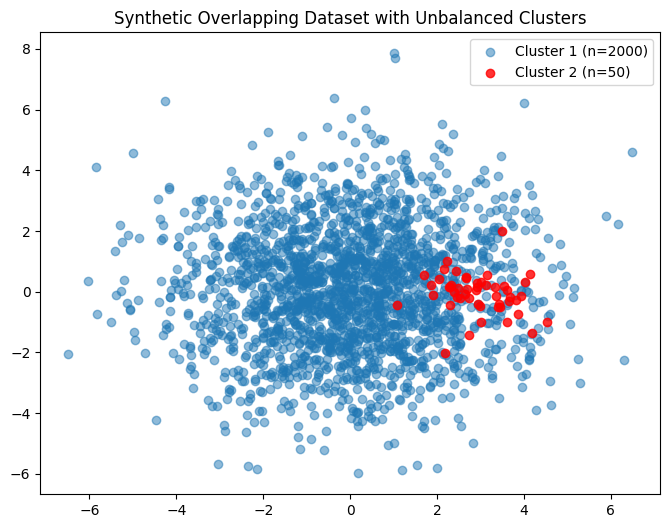

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os

data_dir = 'data'
X = np.load(os.path.join(data_dir, 'X.npy'))
y = np.load(os.path.join(data_dir, 'y.npy'))

plt.figure(figsize=(8,6))
plt.scatter(X[y==0, 0], X[y==0, 1], alpha=0.5, label='Cluster 1 (n=2000)')
plt.scatter(X[y==1, 0], X[y==1, 1], alpha=0.8, color='red', label='Cluster 2 (n=50)')
plt.title('Synthetic Overlapping Dataset with Unbalanced Clusters')
plt.legend()
plt.show()